In [1]:
# 需要：pip install mss python-xlib matplotlib

In [2]:
import os
import mss
import time
import argparse

import Xlib
from Xlib.ext import xtest
from Xlib import display as xdisplay, XK

import numpy as np

In [3]:
class ScreenCapturerMSS():
    def __init__(self, display, rect):
        """使用mss截取屏幕"""
        self.display = display
        self.rect = rect  # (x, y, w, h)
        # mss截屏对象
        self._ctx = None
        # 截屏的区域, 传送给_ctx使用
        self._mon = None

    def start(self):
        os.environ["DISPLAY"] = self.display
        self._ctx = mss.mss()
        x, y, w, h = self.rect
        self._mon = {"left": x, "top": y, "width": w, "height": h}
        self._last = 0.0

    def stop(self):
        self._ctx.close()

    def read(self) -> np.ndarray:
        """截屏并转化为RGB格式numpy对象"""
        sct_img = self._ctx.grab(self._mon)
        img = np.array(sct_img) # shape为[height, width, 4] 4为BGRA
        img = img[..., :3][:, :, ::-1] # 先去掉最后的A, 保留BGR, 再将其翻转, 变为RGB
        return img

In [4]:
class ActuatorXLib():
    """使用Xlib处理鼠标逻辑"""
    def __init__(self, display):
        """初始化, 不做操作"""
        # 直接用传入的 DISPLAY 建立连接（不依赖环境变量）
        self._d = xdisplay.Display(display)
        self._root = self._d.screen().root
        # 获取屏幕宽高
        self.w, self.h = InputController.query_root_size(display)
        self.start()
        
    def start(self):
        """初始化操作"""
        # 构建79位全键盘
        self.keys_list = [
            'Escape', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12',
            'grave', '1', '2', '3', '4', '5', '6', '7', '8', '9', '0', 'minus', 'equal', 'BackSpace',
            'Tab', 'q', 'w', 'e', 'r', 't', 'y', 'u', 'i', 'o', 'p', 'bracketleft', 'bracketright', 'Return',
            'Control_L', 'a', 's', 'd', 'f', 'g', 'h', 'j', 'k', 'l', 'semicolon', 'apostrophe', 'backslash',
            'Shift_L', 'z', 'x', 'c', 'v', 'b', 'n', 'm', 'comma', 'period', 'slash', 'Shift_R',
            'Alt_L', 'space', 'Caps_Lock',
            'Left', 'Up', 'Right', 'Down', 'Insert', 'Delete', 'Home', 'End', 'Prior', 'Next'
        ]
        
        # 预转换 KeyCode, 提高 step 效率
        self.keys_codes = [self._d.keysym_to_keycode(XK.string_to_keysym(k)) for k in self.keys_list]
        
    def key_option(self, key_list):
        """输入键盘操作list, 值仅能取0或1"""
        if len(key_list) != len(self.keys_list):
            print("Error key!")
        for i, key in enumerate(key_list):
            xtest.fake_input(self._d, Xlib.X.KeyPress if key == 1 else Xlib.X.KeyRelease, 
                             self.keys_codes[i])
        self._flush()
        
    def mouse_option(self, mouse_list):
        """输入鼠标操作list, 前三个元素值仅能取0或1, 表示左中右三个按键是否按下, 后三个元素为0到1的浮点数, 表示宽和高"""
        if len(mouse_list) != 5:
            print("Error mouse!")
        
        # 处理鼠标移动逻辑
        mx = int(mouse_list[3] * self.w)
        my = int(mouse_list[4] * self.h)
        xtest.fake_input(self._d, Xlib.X.MotionNotify, x=mx, y=my, root=self._root)
        
        # 处理鼠标点击逻辑
        for idx, mouse in enumerate(mouse_list[:3]):
            xtest.fake_input(self._d, Xlib.X.ButtonPress if mouse==1 else Xlib.X.ButtonRelease, 
                             idx+1)
        
        # 向X服务器发送输入的指令
        self._flush()

    def _flush(self):
        """需要调用该函数才会一次性向虚拟显示器发送输入的指令"""
        self._d.flush()

In [5]:
class InputController:
    """组合截屏与注入"""
    def __init__(self, display):
        """初始化, 不做任何操作"""
        self.display = display
        # 截屏获取
        self.cap = None
        # 键鼠操作
        self.act = None
        
    @staticmethod
    def query_root_size(display):
        """获取虚拟屏幕长宽"""
        env = os.environ.copy()
        env["DISPLAY"] = display
        d = xdisplay.Display()
        s = d.screen()
        w, h = int(s.width_in_pixels), int(s.height_in_pixels)
        d.close()
        return w, h
    
    def start(self):
        self._resolve_window_and_rect()
        # 截屏对象获取
        self.cap = ScreenCapturerMSS(self.display, self.rect)
        self.cap.start()
        # 键鼠输入获取
        self.act = ActuatorXLib(self.display)
      
    def _resolve_window_and_rect(self):
        """设置截屏区域"""
        # 首先设置DISPLAY环境变量
        w, h = InputController.query_root_size(self.display)
        self.rect = (0, 0, w, h)
        return
    
    def get_frame(self):
        return self.cap.read()
    
    def send_action(self, action: {}):
        self.act.key_option(  action[  "key_list"])
        self.act.mouse_option(action["mouse_list"])
        
    def stop(self):
        self.cap.stop()

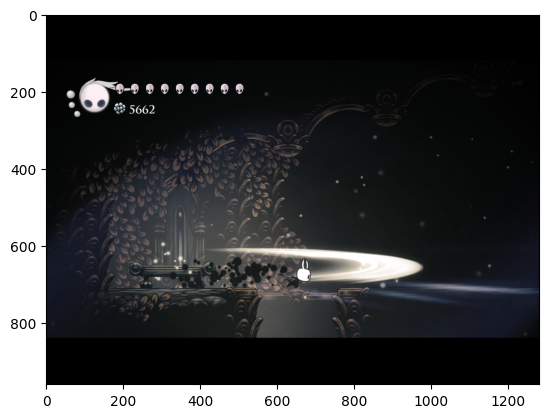

In [7]:
if __name__ == "__main__":
    args = argparse.Namespace(
        display     =     os.getenv('HKRL_DISPLAY',     ':577'),
    )
    
    ic = InputController(args.display)
    ic.start()
    
    import matplotlib.pyplot as plt
    
    ######冲刺劈砍
    
    # 键位对应
    # w     # 上
    # a s d # 左 下 右
    # j k l # 攻 法 闪
    
    # 蓄力攻击2秒
    send_action = {
        "key_list":   [0 for _ in range(29)] + [0] + \
                      [0 for _ in range(12)] + [0, 0, 0] + \
                      [0 for _ in range( 3)] + [1, 0, 0] + [0 for _ in range(28)],
        "mouse_list": [0 for _ in range(5)]
    }
    ic.send_action(send_action)
    time.sleep(2.5)
    # 向右走
    send_action = {
        "key_list":   [0 for _ in range(29)] + [0] + \
                      [0 for _ in range(12)] + [0, 0, 1] + \
                      [0 for _ in range( 3)] + [1, 0, 0] + [0 for _ in range(28)],
        "mouse_list": [0 for _ in range(5)]
    }
    ic.send_action(send_action)
    time.sleep(0.1)
    # 冲刺
    send_action = {
        "key_list":   [0 for _ in range(29)] + [0] + \
                      [0 for _ in range(12)] + [0, 0, 1] + \
                      [0 for _ in range( 3)] + [1, 0, 1] + [0 for _ in range(28)],
        "mouse_list": [0 for _ in range(5)]
    }
    ic.send_action(send_action)
    time.sleep(0.2)
    # 放手攻击
    send_action = {
        "key_list":   [0 for _ in range(29)] + [0] + \
                      [0 for _ in range(12)] + [0, 0, 1] + \
                      [0 for _ in range( 3)] + [0, 0, 1] + [0 for _ in range(28)],
        "mouse_list": [0 for _ in range(5)]
    }
    ic.send_action(send_action)
    # 恢复不动
    send_action = {
        "key_list":   [0 for _ in range(29)] + [0] + \
                      [0 for _ in range(12)] + [0, 0, 0] + \
                      [0 for _ in range( 3)] + [0, 0, 0] + [0 for _ in range(28)],
        "mouse_list": [0 for _ in range(5)]
    }
    ic.send_action(send_action)
    time.sleep(0.2)
    # 截屏展示
    
    plt.imshow(ic.get_frame())
    # ic.stop()

In [8]:
test_img = ic.get_frame()

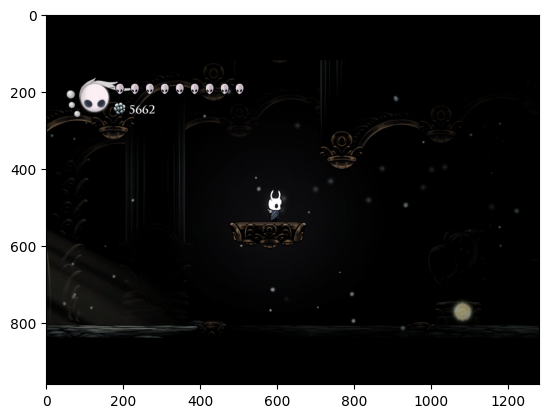

In [10]:
plt.imshow(test_img)

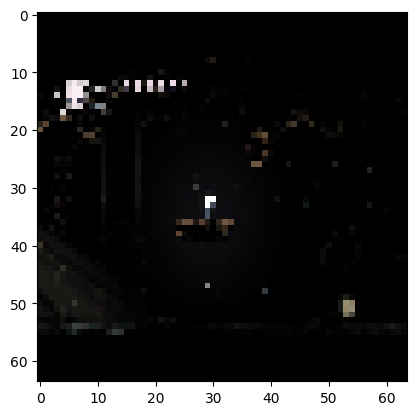

In [11]:
plt.imshow(test_img[(np.linspace(0, 960 - 1, 64)).astype(np.int64)][:, (np.linspace(0, 1280 - 1, 64)).astype(np.int64)])

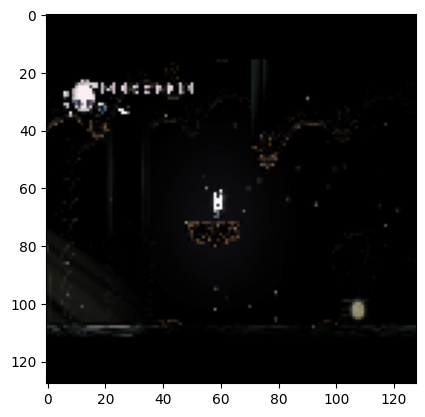

In [12]:
plt.imshow(test_img[(np.linspace(0, 960 - 1, 128)).astype(np.int64)][:, (np.linspace(0, 1280 - 1, 128)).astype(np.int64)])

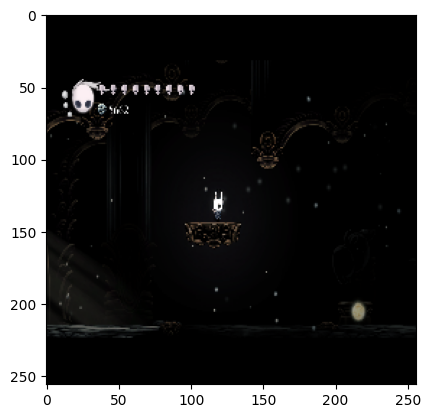

In [13]:
plt.imshow(test_img[(np.linspace(0, 960 - 1, 256)).astype(np.int64)][:, (np.linspace(0, 1280 - 1, 256)).astype(np.int64)])

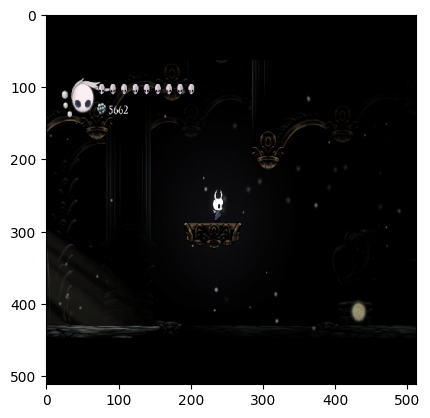

In [14]:
plt.imshow(test_img[(np.linspace(0, 960 - 1, 512)).astype(np.int64)][:, (np.linspace(0, 1280 - 1, 512)).astype(np.int64)])

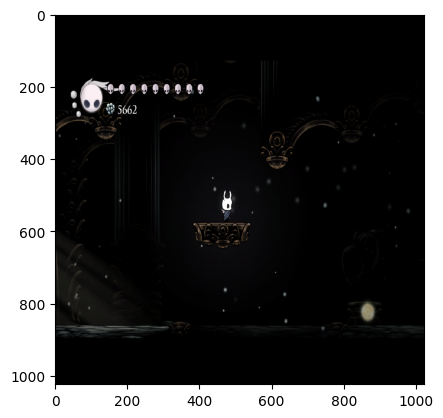

In [15]:
plt.imshow(test_img[(np.linspace(0, 960 - 1, 1024)).astype(np.int64)][:, (np.linspace(0, 1280 - 1, 1024)).astype(np.int64)])

In [16]:
ic.stop()